# Multi-Model P5E Humanization Scoring
Score P5E-humanized texts from multiple humanizer models (Gemini, Llama-70B, Qwen-32B, Llama-4-Scout, Llama-8B) through DNA-DetectLLM.
Compare which humanizer is best at fooling Falcon.

In [1]:
# Install compatible stack: PyTorch 2.5.1 (P100+T4) + matching torchvision + transformers
import subprocess, sys

# Install torch + torchvision together (matching versions)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', 
    '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])

# Install compatible transformers
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])

import torch
print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}, compute {props.major}.{props.minor}, {props.total_memory/1e9:.1f}GB')
    x = torch.randn(2,2).cuda()
    print(f'CUDA test: {(x @ x).sum().item():.2f}')
    del x

import transformers
print(f'Transformers {transformers.__version__}')

# Verify Falcon import
from transformers import AutoModelForCausalLM
print('Falcon model import OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 90.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 66.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 35.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 69.9 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0, 17.1GB
CUDA test: 0.40
Transformers 4.46.3
Falcon model import OK


In [2]:
import gc, os, sys, json, shutil, warnings, zipfile
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

gc.collect()
torch.cuda.empty_cache()

# Auto-find files
BASE = '/kaggle/input'
dataset_file = None
dna_src = None
for root, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'multimodel_p5e_dataset.json':
            dataset_file = os.path.join(root, f)
        if f == '__init__.py' and 'dna_detectllm' in root:
            dna_src = os.path.dirname(os.path.join(root, f))
    for d in dirs:
        if d == 'dna_detectllm':
            candidate = os.path.join(root, d)
            if os.path.isfile(os.path.join(candidate, '__init__.py')):
                dna_src = candidate

print(f'Dataset: {dataset_file}')
print(f'DNA module: {dna_src}')

if not os.path.exists('dna_detectllm') and dna_src:
    shutil.copytree(dna_src, 'dna_detectllm', dirs_exist_ok=True)
    print('Copied dna_detectllm')

assert os.path.exists('dna_detectllm/__init__.py'), 'dna_detectllm not found!'
assert dataset_file, 'multimodel_p5e_dataset.json not found!'

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy

os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
print(f'GPUs: {torch.cuda.device_count()}')

Dataset: /kaggle/input/datasets/mandaliyatanmay/multimodel-p5e-data/multimodel_p5e_dataset.json
DNA module: /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig/dna_detectllm
Copied dna_detectllm
GPUs: 1


In [3]:
# Load dataset
with open(dataset_file) as f:
    dataset = json.load(f)

human_texts = dataset['human_texts']
ai_texts = dataset['original_ai_texts']
N = len(ai_texts)
model_keys = list(dataset['humanized'].keys())
model_labels = dataset['metadata'].get('models', {})

print(f'Base texts: {N}')
print(f'Human texts: {len(human_texts)}')
print(f'Humanizer models:')
for k in model_keys:
    valid = sum(1 for x in dataset['humanized'][k] if x is not None)
    label = model_labels.get(k, k)
    print(f'  {label}: {valid}/{len(dataset["humanized"][k])}')

Base texts: 100
Human texts: 100
Humanizer models:
  Gemini-2.0-Flash: 100/100
  Llama-3.3-70B: 70/100
  Llama-3.1-8B: 100/100
  Llama-4-Scout-17B: 100/100
  Qwen-3-32B: 100/100
  Kimi-K2: 100/100


In [4]:
# Load both models — adapt to GPU type
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc, os, ctypes

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained('tiiuae/falcon-7b')
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512
DEVICE = 'cuda:0'

props = torch.cuda.get_device_properties(0)
compute_cap = (props.major, props.minor)
print(f'GPU: {props.name}, compute {compute_cap[0]}.{compute_cap[1]}')

# T4 (7.5): use 4-bit. P100 (6.0): use fp16 with auto offloading.
if compute_cap >= (7, 0):
    from transformers import BitsAndBytesConfig
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    load_kwargs = dict(quantization_config=quant_config, device_map='auto', low_cpu_mem_usage=True)
    mode = '4-bit'
else:
    load_kwargs = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    mode = 'fp16+auto'

print(f'Loading with {mode}...')
print('Loading observer...')
observer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b', **load_kwargs)
observer.eval()
print(f'Observer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')

gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass

print('Loading performer...')
performer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b-instruct', **load_kwargs)
performer.eval()
print(f'Performer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')
print('Both models loaded!')

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU: Tesla P100-PCIE-16GB, compute 6.0
Loading with fp16+auto...
Loading observer...


config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Performer loaded. GPU: 15.7GB
Both models loaded!


In [5]:
@torch.inference_mode()
def compute_score(text):
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    enc_gpu = {k: v.to(DEVICE) for k, v in enc.items()}
    obs_logits = observer(**enc_gpu).logits.float()
    perf_logits = performer(**enc_gpu).logits.float()
    class EncWrap:
        def __init__(self, d): self.input_ids = d['input_ids']; self.attention_mask = d['attention_mask']
        def to(self, device):
            self.input_ids = self.input_ids.to(device); self.attention_mask = self.attention_mask.to(device)
            return self
    enc_obj = EncWrap(enc_gpu)
    ppl = sum_perplexity(enc_obj, perf_logits)
    x_ppl = entropy(obs_logits, perf_logits, enc_obj, tokenizer.pad_token_id)
    return float(ppl[0] / (2 * x_ppl[0]))

def score_texts(texts, desc='Scoring'):
    scores = []
    for t in tqdm(texts, desc=desc):
        if t is None:
            scores.append(float('nan'))
        else:
            try:
                scores.append(compute_score(t))
            except Exception as e:
                print(f'Error: {e}')
                scores.append(float('nan'))
    return scores

print(f'Sanity: {compute_score("Hello world test sentence"):.4f}')

Sanity: 1.2191


In [6]:
# Score all groups with checkpointing
all_scores = {}

CKPT = 'scores_checkpoint.json'
if os.path.exists(CKPT):
    with open(CKPT) as f:
        all_scores = json.load(f)
    print(f'Loaded checkpoint: {list(all_scores.keys())}')

if 'human' not in all_scores:
    all_scores['human'] = score_texts(human_texts, 'Human')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

if 'original_ai' not in all_scores:
    all_scores['original_ai'] = score_texts(ai_texts, 'Original AI')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

for mk in model_keys:
    if mk not in all_scores:
        label = model_labels.get(mk, mk)
        all_scores[mk] = score_texts(dataset['humanized'][mk], f'P5E via {label}')
        with open(CKPT, 'w') as f: json.dump(all_scores, f)
    else:
        print(f'{mk}: already scored')

print('\nAll scoring complete!')

Human:   3%|▎         | 3/100 [00:15<08:26,  5.22s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 3394 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Human:   4%|▍         | 4/100 [00:20<08:27,  5.29s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 3394 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Human:   6%|▌         | 6/100 [00:30<07:58,  5.09s/it]

...

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 3394 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


P5E via Kimi-K2:  96%|█████████▌| 96/100 [07:51<00:20,  5.08s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 3394 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


P5E via Kimi-K2: 100%|██████████| 100/100 [08:09<00:00,  4.90s/it]


All scoring complete!


In [7]:
# === ANALYSIS ===
def valid(s): return [x for x in s if x is not None and not (isinstance(x, float) and x != x)]

hv = valid(all_scores['human'])
av = valid(all_scores['original_ai'])
hm, am = np.mean(hv), np.mean(av)
gap = hm - am
GMM = 0.6497

print(f'Human mean: {hm:.4f}  |  AI mean: {am:.4f}  |  Gap: {gap:.4f}')
print(f'GMM threshold: {GMM}')
print()

results = {}
print(f'{"Humanizer Model":<35} {"Mean":>7} {"AUROC":>7} {"Gap%":>7} {"Evade%":>7}')
print('='*70)

auroc_ai = roc_auc_score([1]*len(hv)+[0]*len(av), hv+av)
det_ai = sum(1 for s in av if s < GMM)/len(av)*100
print(f'{"Original AI (GPT-4)":<35} {am:>7.4f} {auroc_ai:>7.4f} {0:>6.1f}% {100-det_ai:>6.1f}%')

for mk in model_keys:
    sv = valid(all_scores[mk])
    if len(sv) == 0: continue
    label = model_labels.get(mk, mk)
    m = np.mean(sv)
    auroc = roc_auc_score([1]*len(hv)+[0]*len(sv), hv+sv)
    gap_closed = (m - am) / gap * 100
    evade = sum(1 for s in sv if s >= GMM)/len(sv)*100
    results[mk] = {'label': label, 'mean': m, 'auroc': auroc, 'gap_closed': gap_closed,
                    'evade_rate': evade, 'n': len(sv), 'scores': sv}
    print(f'{label:<35} {m:>7.4f} {auroc:>7.4f} {gap_closed:>6.1f}% {evade:>6.1f}%')

# Rank by AUROC (lower = better at fooling)
ranked = sorted(results.items(), key=lambda x: x[1]['auroc'])
print(f'\n=== RANKING (lower AUROC = better at fooling Falcon) ===')
for i, (mk, r) in enumerate(ranked, 1):
    print(f'{i}. {r["label"]}: AUROC={r["auroc"]:.4f}, Gap={r["gap_closed"]:.1f}%, Evade={r["evade_rate"]:.1f}%')

Human mean: 0.6969  |  AI mean: 0.5978  |  Gap: 0.0991
GMM threshold: 0.6497

Humanizer Model                        Mean   AUROC    Gap%  Evade%
Original AI (GPT-4)                  0.5978  0.9990    0.0%    2.3%
Gemini-2.0-Flash                     0.6994  0.4633  102.5%   98.0%
Llama-3.3-70B                        0.5988  0.9983    1.0%    4.1%
Llama-3.1-8B                         0.5822  0.9987  -15.7%    1.1%
Llama-4-Scout-17B                    0.5964  0.9928   -1.5%    7.4%
Qwen-3-32B                           0.6587  0.8423   61.5%   61.1%
Kimi-K2                              0.7260  0.1965  129.4%  100.0%

=== RANKING (lower AUROC = better at fooling Falcon) ===
1. Kimi-K2: AUROC=0.1965, Gap=129.4%, Evade=100.0%
2. Gemini-2.0-Flash: AUROC=0.4633, Gap=102.5%, Evade=98.0%
3. Qwen-3-32B: AUROC=0.8423, Gap=61.5%, Evade=61.1%
4. Llama-4-Scout-17B: AUROC=0.9928, Gap=-1.5%, Evade=7.4%
5. Llama-3.3-70B: AUROC=0.9983, Gap=1.0%, Evade=4.1%
6. Llama-3.1-8B: AUROC=0.9987, Gap=-15.7%, Evad

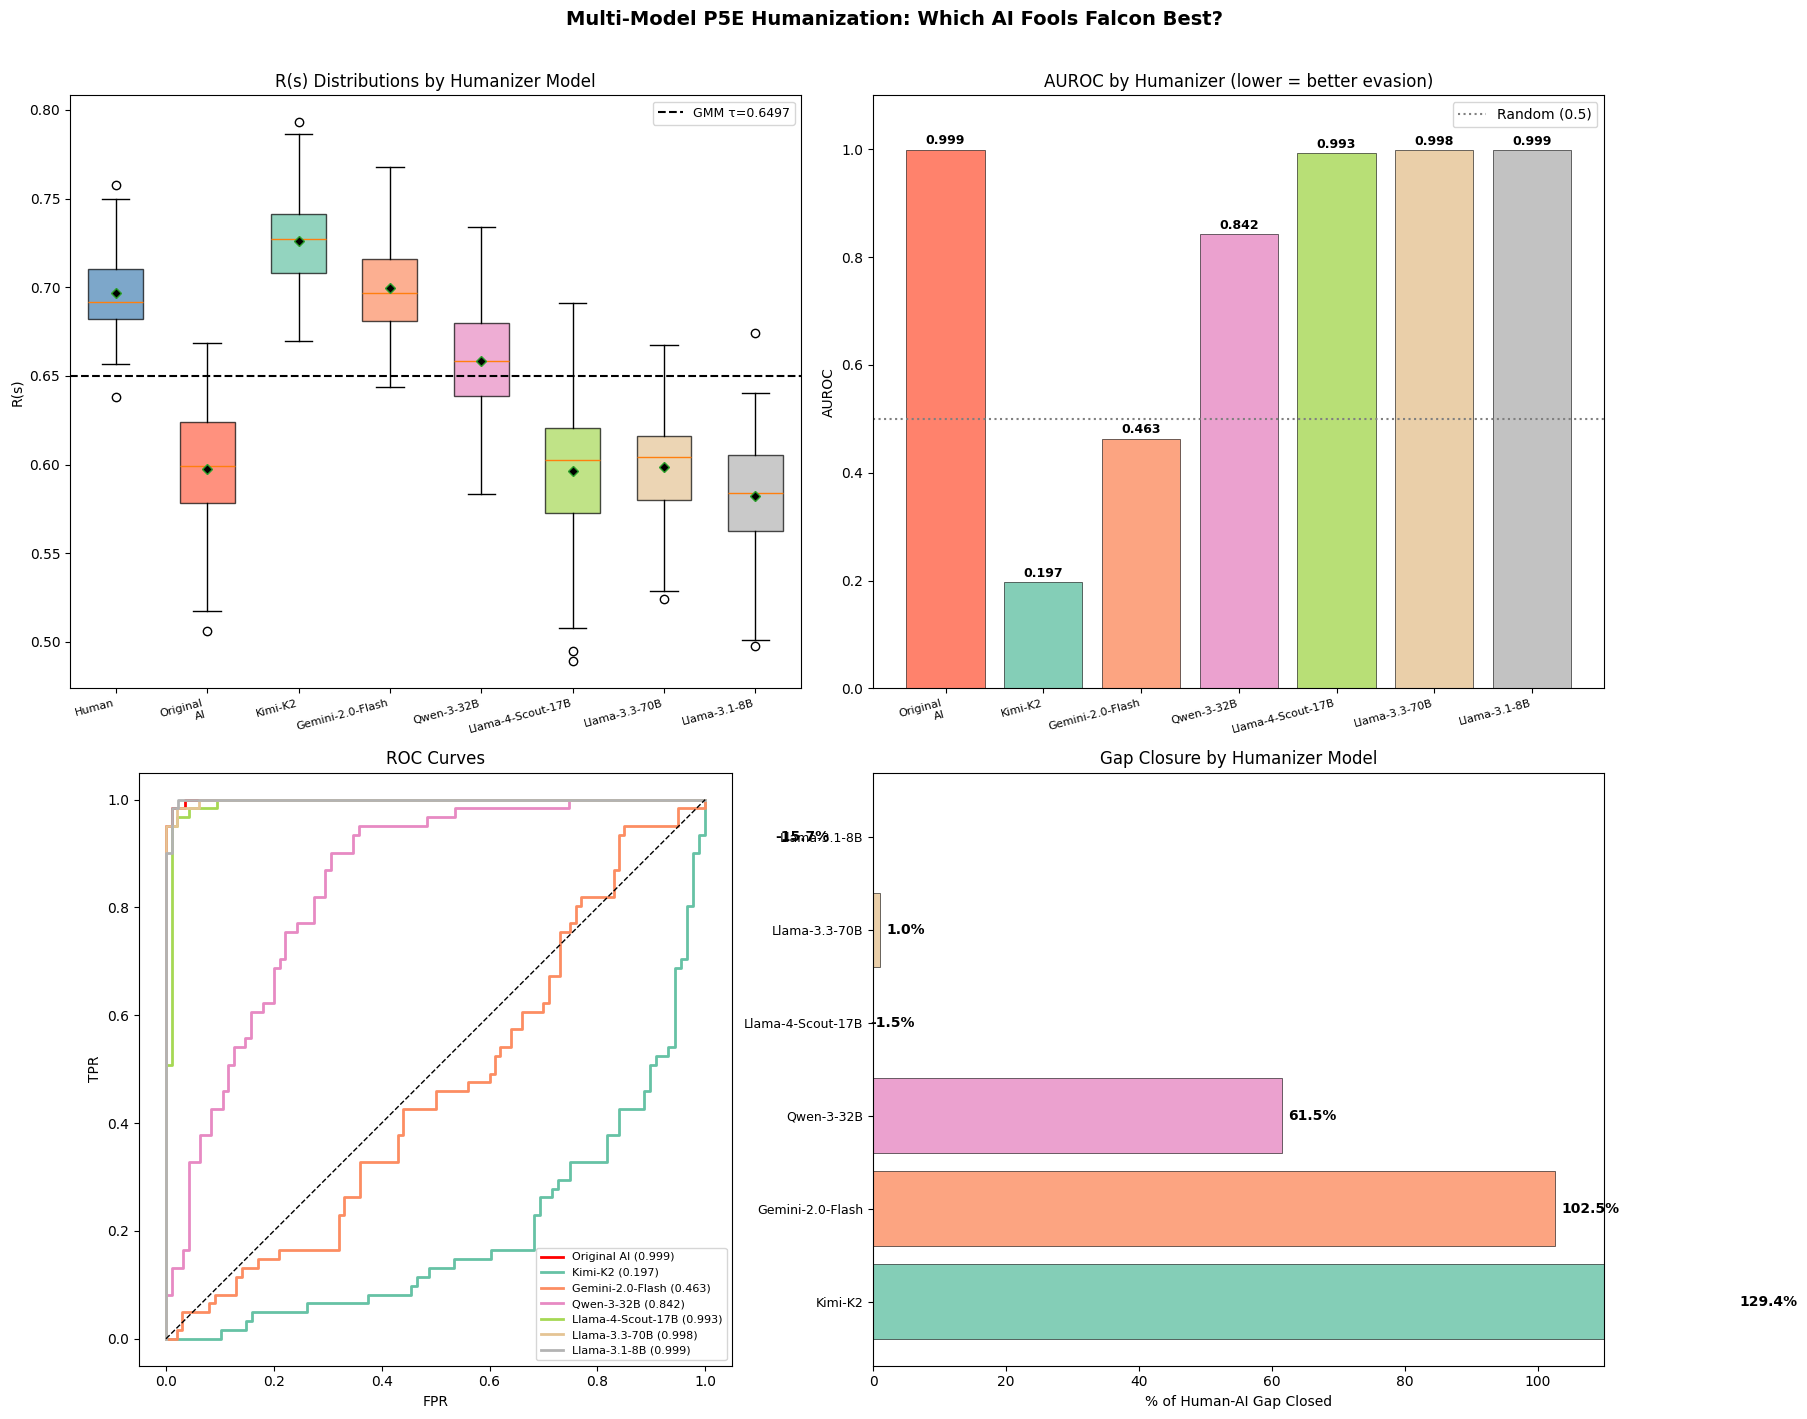

In [8]:
# === PLOTS ===
n_models = len(ranked)
colors = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Boxplots
box_data = [hv, av] + [r['scores'] for _, r in ranked]
box_labels = ['Human', 'Original\nAI'] + [r['label'].replace(' ', '\n', 1) for _, r in ranked]
box_colors = ['steelblue', 'tomato'] + list(colors)
bp = axes[0,0].boxplot(box_data, patch_artist=True, widths=0.6, showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0,0].set_xticklabels(box_labels, fontsize=8, rotation=15, ha='right')
axes[0,0].axhline(GMM, color='black', ls='--', lw=1.5, label=f'GMM τ={GMM}')
axes[0,0].set_ylabel('R(s)'); axes[0,0].set_title('R(s) Distributions by Humanizer Model')
axes[0,0].legend(fontsize=9)

# Plot 2: AUROC comparison bar chart
model_names = ['Original\nAI'] + [r['label'] for _, r in ranked]
aurocs = [auroc_ai] + [r['auroc'] for _, r in ranked]
bar_colors = ['tomato'] + list(colors)
bars = axes[0,1].bar(range(len(aurocs)), aurocs, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
for i, v in enumerate(aurocs):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_xticks(range(len(aurocs)))
axes[0,1].set_xticklabels(model_names, fontsize=8, rotation=15, ha='right')
axes[0,1].axhline(0.5, color='gray', ls=':', label='Random (0.5)')
axes[0,1].set_ylabel('AUROC'); axes[0,1].set_title('AUROC by Humanizer (lower = better evasion)')
axes[0,1].legend(); axes[0,1].set_ylim(0, 1.1)

# Plot 3: ROC curves
fpr_ai, tpr_ai, _ = roc_curve([1]*len(hv)+[0]*len(av), hv+av)
axes[1,0].plot(fpr_ai, tpr_ai, 'r-', lw=2, label=f'Original AI ({auroc_ai:.3f})')
for (mk, r), c in zip(ranked, colors):
    fpr, tpr, _ = roc_curve([1]*len(hv)+[0]*len(r['scores']), hv+r['scores'])
    axes[1,0].plot(fpr, tpr, color=c, lw=2, label=f'{r["label"]} ({r["auroc"]:.3f})')
axes[1,0].plot([0,1],[0,1],'k--',lw=1)
axes[1,0].set_xlabel('FPR'); axes[1,0].set_ylabel('TPR')
axes[1,0].set_title('ROC Curves'); axes[1,0].legend(fontsize=8); axes[1,0].set_aspect('equal')

# Plot 4: Gap closed bar chart
gap_vals = [r['gap_closed'] for _, r in ranked]
bars4 = axes[1,1].barh(range(n_models), gap_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
for i, v in enumerate(gap_vals):
    axes[1,1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1,1].set_yticks(range(n_models))
axes[1,1].set_yticklabels([r['label'] for _, r in ranked], fontsize=9)
axes[1,1].set_xlabel('% of Human-AI Gap Closed')
axes[1,1].set_title('Gap Closure by Humanizer Model')
axes[1,1].set_xlim(0, 110)

plt.suptitle('Multi-Model P5E Humanization: Which AI Fools Falcon Best?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('multimodel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# === SAVE RESULTS ===
output = {
    'experiment': 'Multi-Model P5E Humanization Comparison',
    'prompt': 'P5E_enhanced_lexicon',
    'source_model': 'GPT-4 Turbo',
    'detector': 'Falcon-7B + Falcon-7B-Instruct (DNA-DetectLLM)',
    'n_texts': N,
    'gmm_threshold': GMM,
    'human': {'mean': float(hm), 'std': float(np.std(hv)), 'n': len(hv)},
    'original_ai': {'mean': float(am), 'std': float(np.std(av)), 'n': len(av), 'auroc': float(auroc_ai)},
    'humanizer_models': {}
}
for mk, r in results.items():
    output['humanizer_models'][mk] = {
        'label': r['label'], 'mean': float(r['mean']),
        'std': float(np.std(r['scores'])), 'n': r['n'],
        'auroc': float(r['auroc']), 'gap_closed': float(r['gap_closed']),
        'evade_rate': float(r['evade_rate']),
    }
output['all_scores'] = {k: [float(s) if s == s else None for s in v] for k, v in all_scores.items()}

with open('multimodel_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print('Saved multimodel_results.json')

# Print summary
print(f'\n{"="*60}')
print('SUMMARY')
print(f'{"="*60}')
best_mk, best_r = ranked[0]
print(f'Best humanizer: {best_r["label"]}')
print(f'  AUROC: {best_r["auroc"]:.4f} (vs Original AI: {auroc_ai:.4f})')
print(f'  Gap closed: {best_r["gap_closed"]:.1f}%')
print(f'  Evasion rate: {best_r["evade_rate"]:.1f}%')

Saved multimodel_results.json

SUMMARY
Best humanizer: Kimi-K2
  AUROC: 0.1965 (vs Original AI: 0.9990)
  Gap closed: 129.4%
  Evasion rate: 100.0%
